Submitted by Group 11:

- Ehsan Attar
- Name2
- Name3
- Name4

By submitting this exercise, you confirm the following:

- **All people** listed above **contributed** to this solution
- **No other people** were **involved** in this solution
- **No contents** of this solution were **copied from others** (this includes people, large language models, websites, etc.)

In [1]:
import cv2
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import requests
from PIL import Image

<p style="page-break-after:always;"></p>

# Helper Function

In [2]:
  
def plot_distribution(*outputs, figsize=None):
    if figsize is None:
        figsize = (5 * len(outputs), 3)
    plt.figure(figsize=figsize)
    for i, out in enumerate(outputs):
        prefix = f"{i+1}. "
        plt.subplot(1,len(outputs),i+1)
        plt.title(f"{prefix}Shape={out.shape}; Max={out.max():.4f}@{out.argmax()}")
        if out.sum() < 0.99999999:
            print("WARNING: Sum not 1, but should be. Sum={out.sum():.4f}")
        plt.plot(out)
    plt.show()

<p style="page-break-after:always;"></p>

# Task: Recursive Bayes Filter
---

Often we want to know the state of a dynamical system.
Sometimes the state can be directly observed, e.g. chess figures, whereas in other cases the state is unknown, e.g. location of an autonomous robot.
Here we will have a look at the case where we cannot directly observe the case, but have to estimate it.

<div style="background-color: #042c58; color: #ffffff; width: 100%; padding: 0.3em; font-size:1.1em; font-weight: bold;">Definition: System with Hidden State</div>
<div style="background-color: #d7e9fd; width: 100%; padding-top: 0.5em; padding-bottom: 0.3em">

A system where we cannot directly observe the state consists of the following components:

* Timestep: $t$
* True State: $x_{t}$ (sometimes $\mu$)
* Estimated State: $\hat{x}_{t}$ (also $\texttt{bel}(x_t)$)
* Observations/Measurements: $z_{t}$
* Measurement model: $p(z_{t}|x_{t})$
* Motion model: $p(x_{t}|x_{t-1},u_{t})$

</div>

Let's look at a concrete example: An autonomus train.
* The state $x$ of the train would be the distance along the track covered $d$ $\rightarrow x_{t} = d_t$.
* The train can measure if it is at a train station or on the open track, resulting in a measurement model $p(z_{t}|x_{t})$. But it cannot directly measure where it is on the track.
* The speed at which the train moves can be controlled. However, the speed lever is a bit loose, so the actual speed is a gaussian distribution with $C_u$ around a mean $\mu_u$. Thus, we have a motion model $p(x_{t}|x_{t-1},u_{t})$ which returns a probability distribution of the motion.
* Initially the train does not know where it is, thus we assume a equal distribution for he belief initially.

The task is to estimate the position of the robot iteratively using recursive bayes filter.

## Motion Model

In the the recursive bayes formula we need a motion model $p(x_{t}|x_{t-1},u_{t})$ but as the lever is loose, this is a gaussian distribution. This means we will have to implement a gaussian distribution first.

In our train example the motion model is mathematically defined as: $p(x_{t}|x_{t-1},u_{t}) = \texttt{norm}(x_{t-1} + u_{t}, C_u)$

**Task:** Implement the train's motion model.
* Implement `p_motion_model(x_old, u) -> arr` which returns an array that contains the probability distribution as a 1d array. The indices of the output correspond to the probabilities:
    * $\forall x_t: \texttt{p\_motion\_model}(x_{t-1}, u)[x_t] = p(x_{t}|x_{t-1},u_{t})$
    * The previous belief $x_{t-1}$ is `x_old`.
    * The covariance $C_u$ is `C_u`.
    * The control input $u$ is `u`.

Allowed Functions: `np.arange(...)`, `np.array(...)`, `np.sum(...)`, `np.exp(...)`.

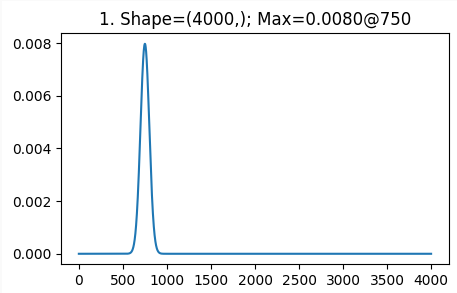

**Fig**: The output should look like this. You can see a gaussian with a peak at 750.

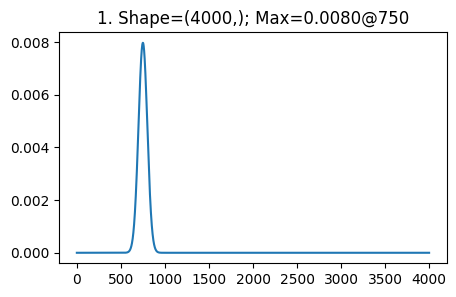

In [3]:
def gaussian_dist(mu, sigma, start=0, stop=4000):
    # Fill an array with probabilities of a Gaussian distribution
    x = np.arange(start, stop)
    arr = np.exp(-0.5 * ((x - mu) / sigma) ** 2)
    arr = arr / np.sum(arr)
    return arr

def p_motion_model(x_old, u, C_u=50):
    # The expected new position is old position + control input
    mu = x_old + u
    arr = gaussian_dist(mu, C_u, 0, 4000)
    return arr

out = p_motion_model(x_old=500, u=250)
plot_distribution(out)

## Measurement Model

Next we need to define where the trainstations are and thus our measurement model. Trainstations are positioned at 1000, 1500 and 3500. The train observes the station when it is at the position of the trainstation with a variance of 50 units.

Generally we have two cases to differentiate:
1. We observe the station.
2. We do not observe it.

In the case we observe the station it means we have a gaussian mixture of where we could be. We mix the 3 gaussians centered at 1000, 1500 and 3500 each with a variance of 50. We weight all gassians by a weight of 1/3.

In the case we do not observe the station we create the inverse of the above case. note though that the sum of a distribution must always be 1.0!

**Task:**
* Implement a function `p_measured_station()` returning an array representing gaussian mixture distribution.
* Implement a function `p_not measured_station()` which is the inverse.

*Hint: The sum of a distribution must be 1.0.*

Allowed Functions: `np.sum(...)` and functions defined in tasks above.

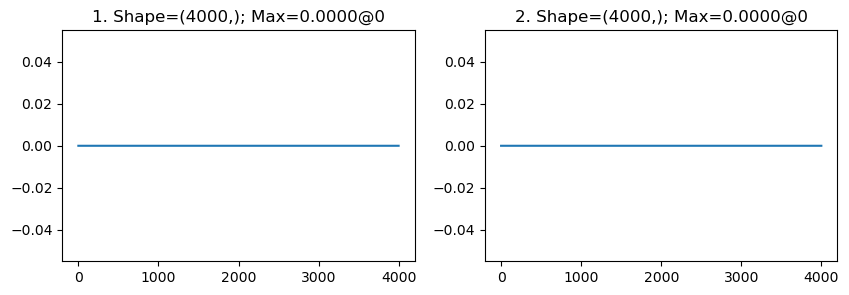

In [4]:
def p_measured_station(C_m=50):
    # TODO fill array with correct values
    arr = np.zeros((4000,))
    return arr

def p_not_measured_station(C_m=50):
    # TODO invert p_measured_station
    arr = np.zeros((4000,))
    return arr

plot_distribution(
    p_measured_station(),
    p_not_measured_station()
)

## Recursive Bayes Prediction

With all components ready it is time to estimate the location of the train.

<div style="background-color: #042c58; color: #ffffff; width: 100%; padding: 0.3em; font-size:1.1em; font-weight: bold;">Definition: Recursive Bayes Formula</div>
<div style="background-color: #d7e9fd; width: 100%; padding-top: 0.5em; padding-bottom: 0.3em">

We compute the belief of the current timestep using a measurement model $p(z_{t}|x_{t})$, motion model $p(x_{t}|x_{t-1},u_{t})$ and the belief from the previous state:

$$\texttt{bel}(x_t) = \eta \cdot p(z_t|x_t) \int p(x_t|x_{t-1}, u_t) \cdot \texttt{bel}(x_{t-1}) dx_{t-1}$$

<center>and in a discrete case</center>

$$\texttt{bel}(x_t) = \eta \cdot p(z_t|x_t) \sum_{x_{t-1}} p(x_t|x_{t-1}, u_t) \cdot \texttt{bel}(x_{t-1})$$

</div>

**Task:** Implement recursive Bayes
* Implement the function `bel_x = update_belief(bel_x, u, sees_station)` using the recursive bayes method and the functions implemented above.
* Let's assume the train does the following:
    1. Move 50 then observe a station
    2. Move 200 then observe no station
    3. Move 300 then observe a station


Allowed Functions: `np.zeros(...)`, `np.ones(...)`, `np.sum(...)` and the functions you defined in above tasks.

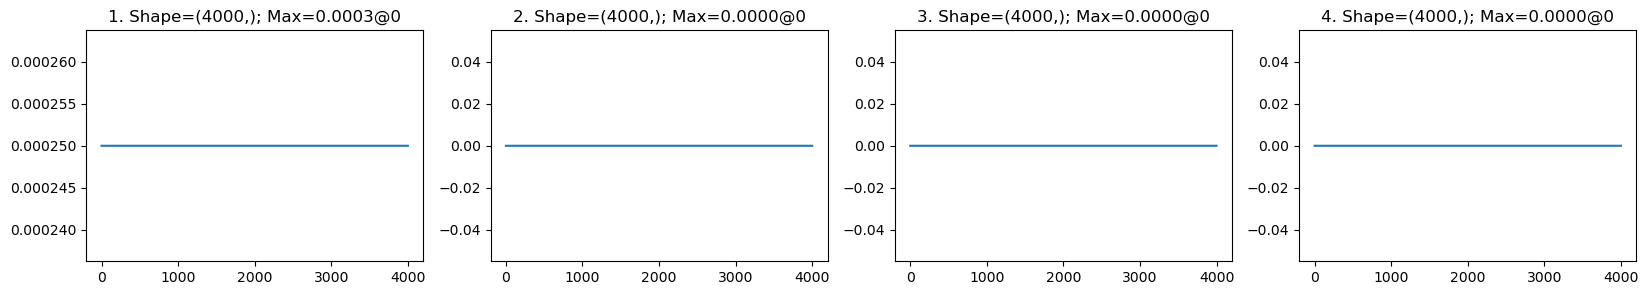

In [5]:
# Solution
initial_belief = np.ones(4000) / 4000

def update_belief(bel_x, u, sees_station):
    # TODO propagate belief
    arr = np.zeros(4000)
    return arr

history = [
    (50, True),
    (200, False),
    (300, True),
]

beliefs = [initial_belief]
for i, (u, station) in enumerate(history):
    beliefs.append(update_belief(beliefs[-1], u, station))

plot_distribution(*beliefs)

<p style="page-break-after:always;"></p>

# Task: Kalman Filter
---

Above example is actually a quite amazing example, because we can localize the train without any idea where it is and even the measurements give us just a multimodal distribution where we could be. Just by combining all information the train can be localized.

In the next case, we have a much simpler problem setting (despite a more complicated explanation), which allows us to implement a more efficient and fast solution: The Kalman Filter.
It is used to predict the state of a linear system with gaussian distribution.

Imagine an autonomous robot driving indoors.
* The state is the position of the robot $x = (p_x, p_y)$. And the state does not change without control input $\rightarrow A = I$ (identity matrix for state transition matrix). 
* The robot can move in x and y direction resulting in a control sequence $u = (v_x, v_y)$. The velocity is linearily applied assuming a constant time delay ($\Delta_t$) $\rightarrow B = \Delta_t \cdot I$.
* As measurements we can measure $z$ using a measurement function $H$ (H defined later): $z = Hx$.

The matrices $A$ and $B$ would be:
$$
A =
\left[ {\begin{array}{cc}
1 & 0 \\
0 & 1 \\
\end{array} } \right]
$$

$$
B =
\left[ {\begin{array}{cc}
\Delta_t & 0 \\
0 & \Delta_t \\
\end{array} } \right]
$$

<div style="background-color: #042c58; color: #ffffff; width: 100%; padding: 0.3em; font-size:1.1em; font-weight: bold;">Definition: Kalman Filter</div>
<div style="background-color: #d7e9fd; width: 100%; padding-top: 0.5em; padding-bottom: 0.3em">
    
**Time Update** (aka Prediction) step using $A, B, x, u$, estimated system covariance matrix $\hat{C}$ and motion covariance matrix $C^u$.

$$x \leftarrow A x + B u$$

$$\hat{C} \leftarrow A \hat{C} A^T + C^u$$

**Measurement Update** (aka Measurement) step of the kalman filter using $H, x, z$, estimated system covariance matrix $\hat{C}$ and measurement covariance matrix $C^m$. Define an intermediate variable for the Kalman Gain $K$.

$$K = \hat{C} H^T (H \hat{C} H^T + C^m)^{-1}$$

$$ x \leftarrow x + K ( z - Hx)$$

$$\hat{C} \leftarrow (I-KH)\hat{C}$$

</div>

**TASK**:
* Implement the time update and measurement update using numpy (you only need np.dot and basic operators). Assume H to be:

$$
H =
\left[ {\begin{array}{cc}
0.8 & 0.2 \\
0.2 & 0.8 \\
\end{array} } \right]
$$

Allowed Functions: `np.array(...)`, `np.dot(...)`.

In [6]:
# Covariance for measurement and motion
C_u = np.array([
    [0.2, 0],
    [0, 0.2]
])
C_m = np.array([
    [0.2, 0.01],
    [0.01, 0.2]
])
H = np.array([
    [0.8, 0.2],
    [0.2, 0.8]
])

# Implement the filter
def predict(x, C_hat, u):
    # TODO
    return x, C_hat

def measure(x, C_hat, z):
    # TODO
    return x, C_hat

# Initial estimate (wide distribution as we have no clue)
x = np.array([5.,5.])
C_hat = np.array([
    [10., 0.],
    [0., 10.]
])

# Simulate and run filter
x_true = np.array([4.,4.])
motions = np.array([
    [3., 1.],
    [-3., 3.],
    [1., -2.],
    [1., -3.],
])
for i, u in enumerate(motions):
    x_true += u
    z = np.dot(H, x_true)
    print(f"X_True", x_true)
    x, C_hat = predict(x, C_hat, u)
    print("Pred", x, C_hat.flatten())
    x, C_hat = measure(x, C_hat, z)
    print("Measure", x, C_hat.flatten())

X_True [7. 5.]
Pred [5. 5.] [10.  0.  0. 10.]
Measure [5. 5.] [10.  0.  0. 10.]
X_True [4. 8.]
Pred [5. 5.] [10.  0.  0. 10.]
Measure [5. 5.] [10.  0.  0. 10.]
X_True [5. 6.]
Pred [5. 5.] [10.  0.  0. 10.]
Measure [5. 5.] [10.  0.  0. 10.]
X_True [6. 3.]
Pred [5. 5.] [10.  0.  0. 10.]
Measure [5. 5.] [10.  0.  0. 10.]
